# IPL Player Auction Price Prediction System

### 🎯 Problem Statement
- In the Indian Premier League (IPL), franchises invest heavily in players during auctions. However, deciding how much a player is worth is complex and depends on multiple factors like past performance, experience, and skills.


### 🔍 Objective:
- Build a regression model that predicts the auction price of a player using performance metrics and player characteristics.


# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\pavan\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## 2. Load the data

In [2]:
df = pd.read_csv("IPL_Auction_Player_Performance_Analytics.csv")
print(df.shape)
df.head()

(12000, 13)


,Name,Age,Country,Role,Matches,Experience ( in Yrs),Runs,Strike_Rate,Wickets,Economy,Average,Team_Preference,Auction_Price ( in Cr )
0,MS Dhoni,42,India,Wicketkeeper,350,20,12000,135.0,0,0.00,50.00,CSK,20.0
1,Sachin Tendulkar,45,India,Batter,400,24,18000,125.0,5,8.50,45.00,MI,1.5
2,Virat Kohli,36,India,Batter,300,16,13000,138.0,2,7.00,52.00,RCB,18.0
3,Rohit Sharma,37,India,Batter,280,17,14000,132.0,0,8.00,48.00,MI,18.0
4,Jasprit Bumrah,35,India,Bowler,196,7,2661,144.9,798,7.69,27.43,MI,12.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Name                     12000 non-null  str    
 1   Age                      12000 non-null  int64  
 2   Country                  12000 non-null  str    
 3   Role                     12000 non-null  str    
 4   Matches                  12000 non-null  int64  
 5   Experience ( in Yrs)     12000 non-null  int64  
 6   Runs                     12000 non-null  int64  
 7   Strike_Rate              12000 non-null  float64
 8   Wickets                  12000 non-null  int64  
 9   Economy                  12000 non-null  float64
 10  Average                  12000 non-null  float64
 11  Team_Preference          12000 non-null  str    
 12  Auction_Price ( in Cr )  12000 non-null  float64
dtypes: float64(4), int64(5), str(4)
memory usage: 1.5 MB


In [4]:
df.describe()

,Age,Matches,Experience ( in Yrs),Runs,Strike_Rate,Wickets,Economy,Average,Auction_Price ( in Cr )
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,30.094667,146.447167,6.523083,5897.813833,125.118867,191.803500,5.068873,37.386248,3.729067
std,7.191883,125.774590,5.361237,3630.126361,17.270469,246.319993,3.167495,10.094644,3.693414
min,18.000000,15.000000,1.000000,0.000000,95.000000,0.000000,0.000000,20.000000,0.200000
25%,24.000000,46.000000,2.000000,2986.750000,110.300000,0.000000,0.000000,28.570000,1.000000
50%,30.000000,108.000000,5.000000,5359.500000,125.200000,15.000000,6.220000,37.340000,2.000000
75%,36.000000,217.000000,10.000000,8450.250000,140.100000,351.000000,7.420000,46.092500,5.000000
max,45.000000,713.000000,24.000000,18000.000000,155.000000,900.000000,9.500000,55.000000,20.000000


In [5]:
print(df.isnull().sum())
f"Duplicate rows: {df.duplicated().sum()}"

Name                       0
Age                        0
Country                    0
Role                       0
Matches                    0
Experience ( in Yrs)       0
Runs                       0
Strike_Rate                0
Wickets                    0
Economy                    0
Average                    0
Team_Preference            0
Auction_Price ( in Cr )    0
dtype: int64


'Duplicate rows: 0'

In [6]:
Total_Players=len(df['Name'].unique())
Total_Players

321

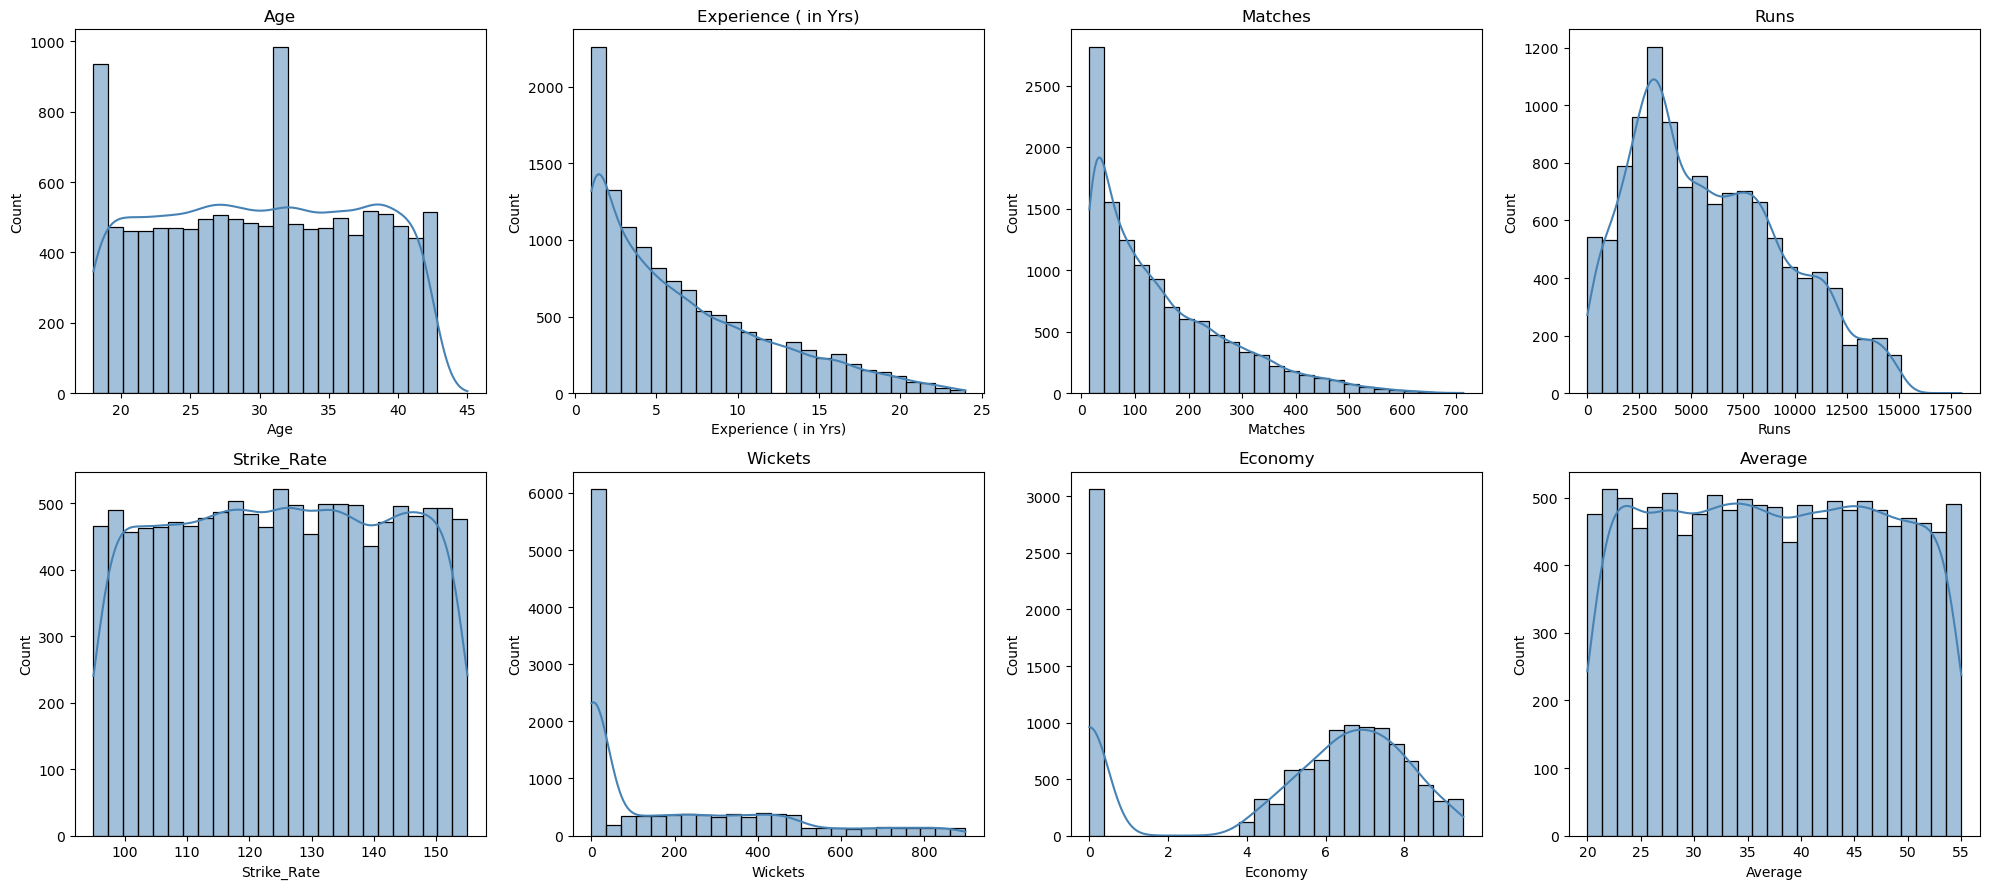

In [7]:
num_features_to_plot = ["Age", "Experience ( in Yrs)", "Matches", "Runs", "Strike_Rate", "Wickets", "Economy", "Average"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, col in enumerate(num_features_to_plot):
    sns.histplot(df[col], bins=25, kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

**Insight:** All the performance stats (Runs, Wickets, Strike Rate, Economy, Average) span wide, plausible cricket ranges — the data isn't obviously broken, it just doesn't drive price (confirmed next).

Country
New Zealand     6.10
Afghanistan     4.67
Sri Lanka       3.75
India           3.75
South Africa    3.75
England         3.75
Australia       3.65
West Indies     3.64
Pakistan        3.59
Name: Auction_Price ( in Cr ), dtype: float64


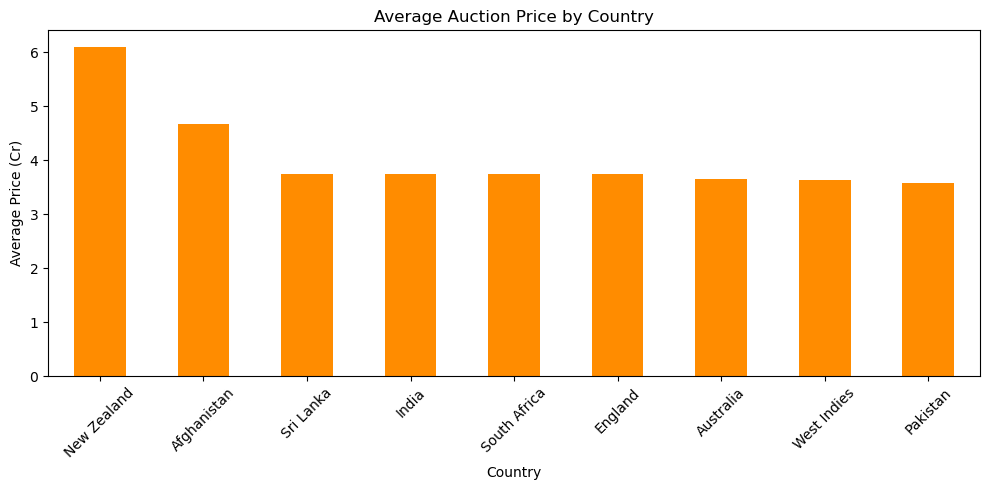

In [14]:
avg_price_by_country = df.groupby("Country")["Auction_Price ( in Cr )"].mean().sort_values(ascending=False)
print(avg_price_by_country.round(2))

plt.figure(figsize=(10, 5))
avg_price_by_country.plot(kind="bar", color="darkorange")
plt.title("Average Auction Price by Country")
plt.ylabel("Average Price (Cr)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight:** Average price stays (~3.6–4 Cr) across every country, including the very small-sample countries (New Zealand, Afghanistan, Pakistan)
- India — the largest and most in-demand pool
- clearly  Indai has higher average than smaller overseas pools

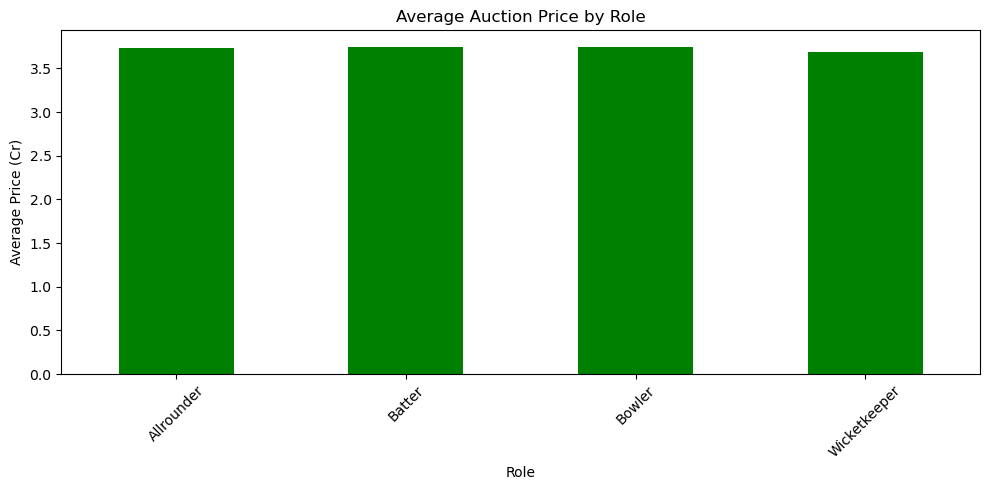

Role
Allrounder      3.732289
Batter          3.748168
Bowler          3.744268
Wicketkeeper    3.692529
Name: Auction_Price ( in Cr ), dtype: float64


In [24]:
avg_price_by_role=df.groupby("Role")["Auction_Price ( in Cr )"].mean()
plt.figure(figsize=(10, 5))
avg_price_by_role.plot(kind="bar", color="green")
plt.title("Average Auction Price by Role")
plt.ylabel("Average Price (Cr)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(avg_price_by_role)

**Insight** Average price by each role is 3.7 cr 

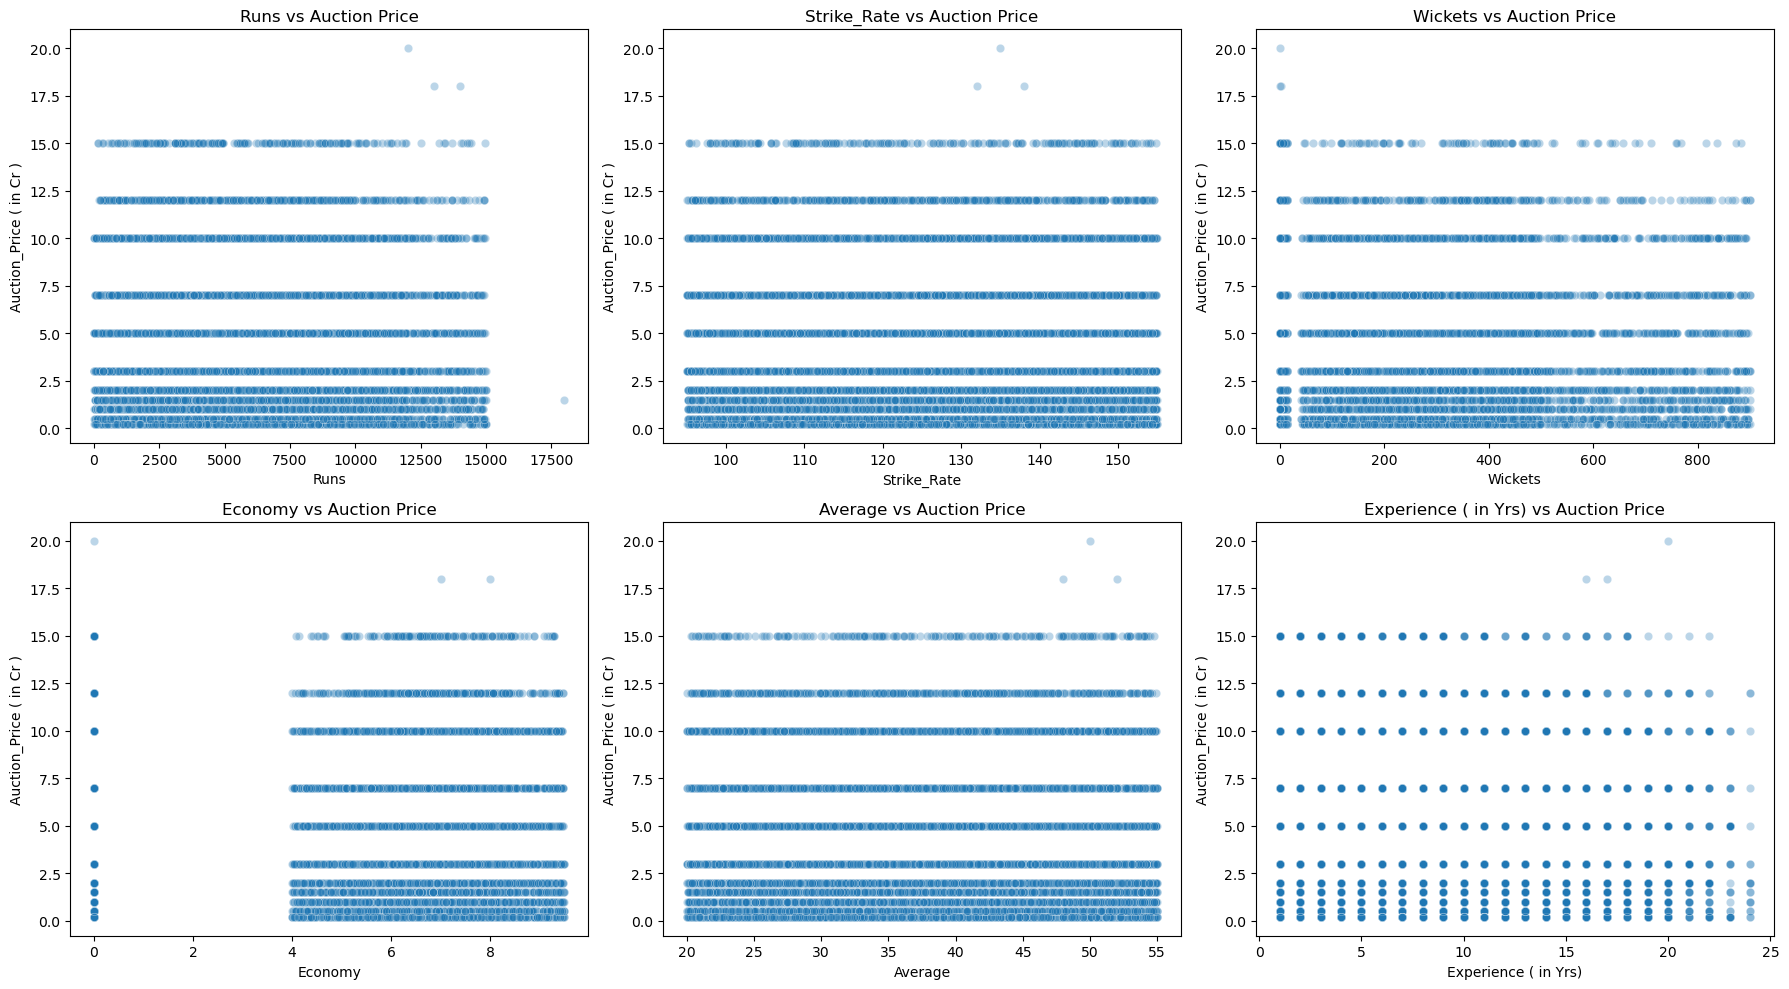

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
scatter_cols = ["Runs", "Strike_Rate", "Wickets", "Economy", "Average", "Experience ( in Yrs)"]
for i, col in enumerate(scatter_cols):
    r, c = divmod(i, 3)
    sns.scatterplot(data=df, x=col, y="Auction_Price ( in Cr )", alpha=0.3, ax=axes[r][c])
    axes[r][c].set_title(f"{col} vs Auction Price")
plt.tight_layout()
plt.show()

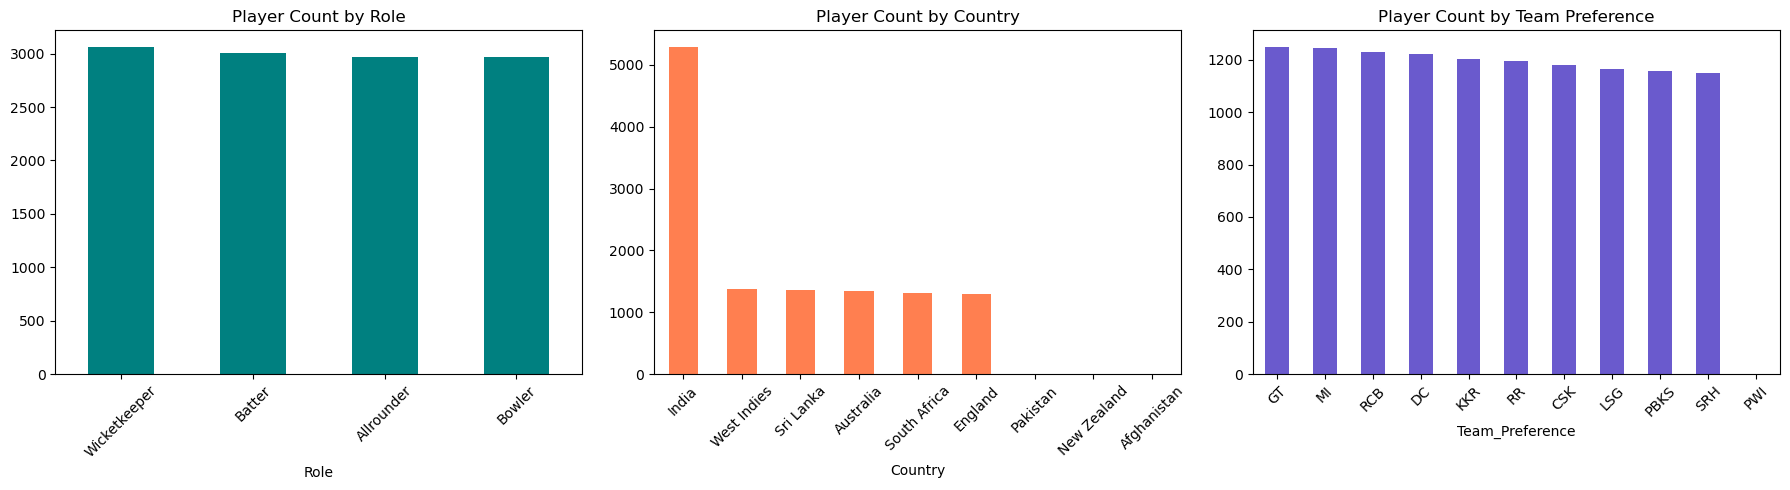

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
df["Role"].value_counts().plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Player Count by Role")
axes[0].tick_params(axis="x", rotation=45)

df["Country"].value_counts().plot(kind="bar", ax=axes[1], color="coral")
axes[1].set_title("Player Count by Country")
axes[1].tick_params(axis="x", rotation=45)

df["Team_Preference"].value_counts().plot(kind="bar", ax=axes[2], color="slateblue")
axes[2].set_title("Player Count by Team Preference")
axes[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

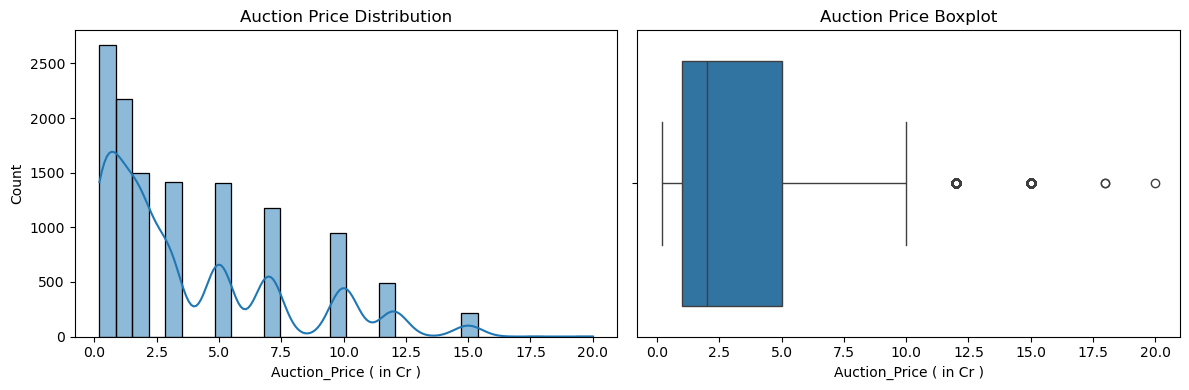

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Auction_Price ( in Cr )"], bins=30, kde=True, ax=ax[0])
ax[0].set_title("Auction Price Distribution")
sns.boxplot(x=df["Auction_Price ( in Cr )"], ax=ax[1])
ax[1].set_title("Auction Price Boxplot")
plt.tight_layout()
plt.show()

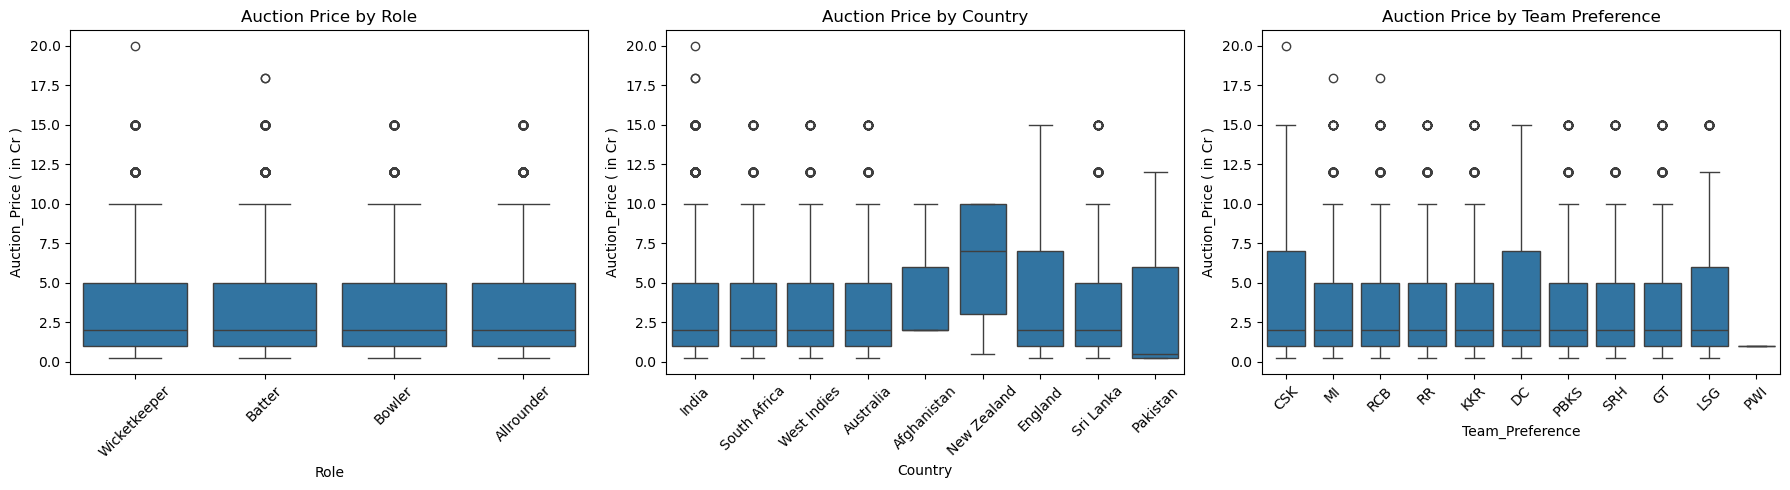

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df, x="Role", y="Auction_Price ( in Cr )", ax=ax[0])
ax[0].set_title("Auction Price by Role")
ax[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="Country", y="Auction_Price ( in Cr )", ax=ax[1])
ax[1].set_title("Auction Price by Country")
ax[1].tick_params(axis="x", rotation=45)

sns.boxplot(data=df, x="Team_Preference", y="Auction_Price ( in Cr )", ax=ax[2])
ax[2].set_title("Auction Price by Team Preference")
ax[2].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

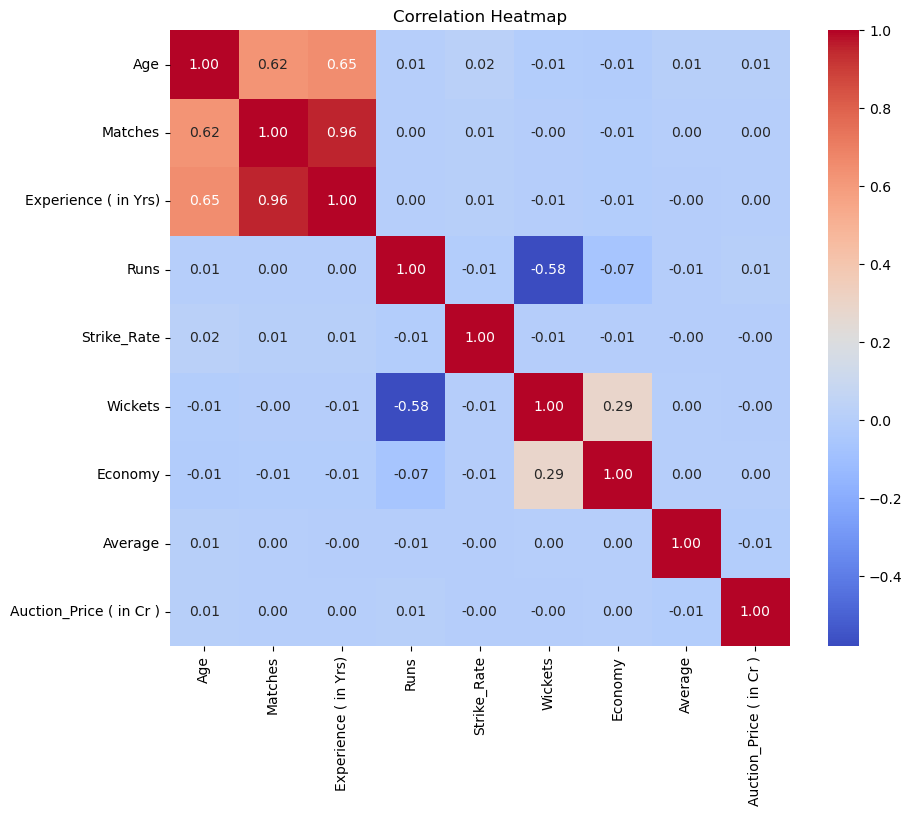

In [12]:
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### EDA Summary — Key Insights
1. **No linear relationship**: Every numeric feature correlates with `Auction_Price` at essentially 0 (|r| < 0.02 across the board in the heatmap).
2. **No categorical effect either**: Mean/median price is flat across Role, Country, and Team_Preference — real auctions would show batters, Indian players, and star-heavy teams paying premiums.
3. **Scatter plots show pure noise**: Runs vs Price, Wickets vs Price, Strike Rate vs Price, etc. all look like random clouds with no visible trend line.
4. **Price distribution is flat, not skewed**: Real auction prices are right-skewed (few very expensive stars); this column looks closer to uniformly random.
5. **Conclusion**: `Auction_Price` in this file behaves as if it was generated independently of the player stats — likely placeholder/random values rather than a real (or realistically simulated) auction outcome.